In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df=pd.read_csv("tip.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [72]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [73]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

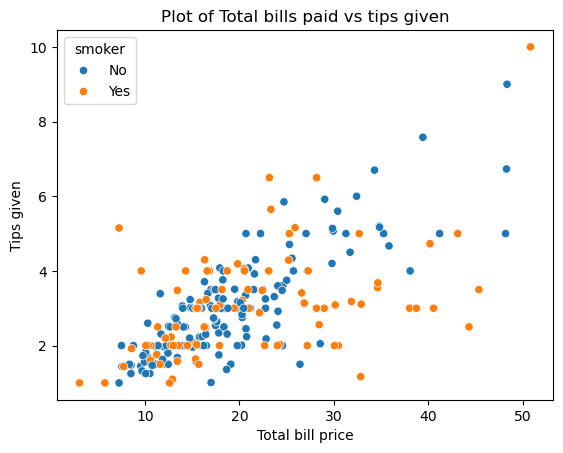

In [74]:
sns.scatterplot(x=df["total_bill"],y=df["tip"],hue=df["smoker"])
plt.xlabel("Total bill price")
plt.ylabel("Tips given")
plt.title("Plot of Total bills paid vs tips given")
plt.show()

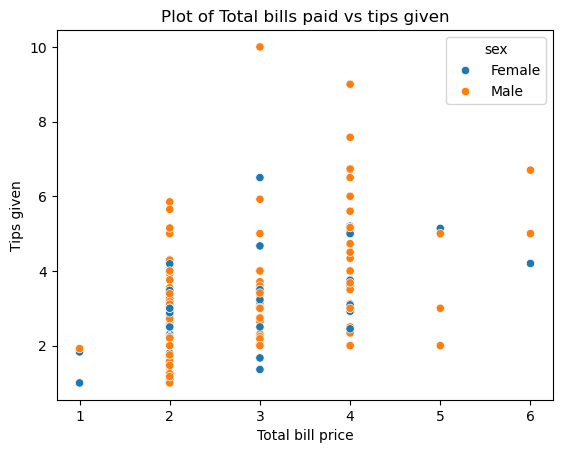

In [75]:
sns.scatterplot(x=df["size"],y=df["tip"],hue=df["sex"])
plt.xlabel("Total bill price")
plt.ylabel("Tips given")
plt.title("Plot of Total bills paid vs tips given")
plt.show()

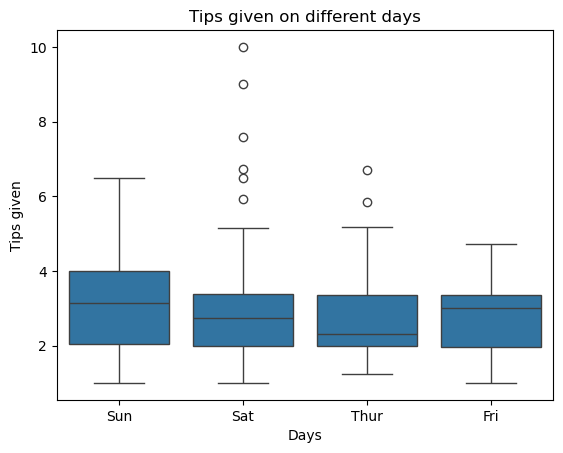

In [76]:
sns.boxplot(x=df["day"],y=df["tip"])
plt.title("Tips given on different days")
plt.xlabel("Days")
plt.ylabel("Tips given")
plt.show()

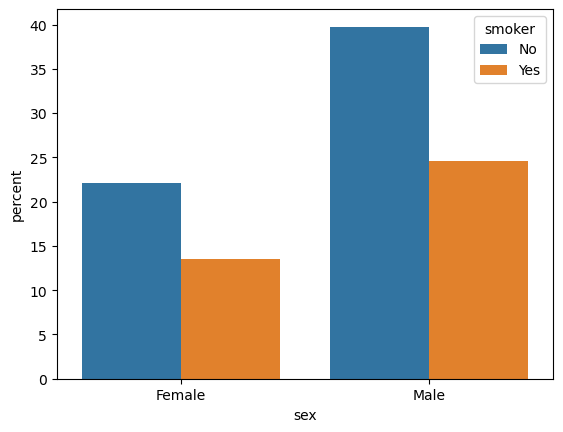

In [77]:
sns.countplot(x=df["sex"],hue=df["smoker"],stat="percent")
plt.show()

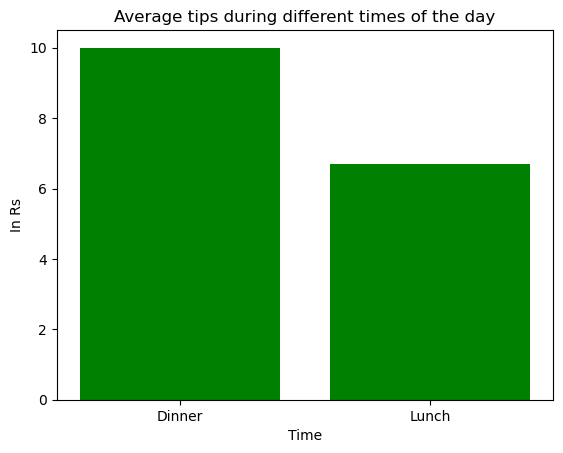

In [78]:
plt.bar(df["time"],df["tip"],color="g")
plt.title("Average tips during different times of the day")
plt.xlabel("Time")
plt.ylabel("In Rs")
plt.show()

In [79]:
df["time"]=df["time"].apply(lambda x:1 if x=="Dinner" else 0)

In [80]:
df["time"].value_counts()

time
1    176
0     68
Name: count, dtype: int64

In [81]:
df["sex"]=df["sex"].apply(lambda x:1 if x=="Male" else 0)

In [82]:
df["sex"].value_counts()

sex
1    157
0     87
Name: count, dtype: int64

In [83]:
df["smoker"]=df["smoker"].apply(lambda x:1 if x=="No" else 0)

In [84]:
df["smoker"].value_counts()

smoker
1    151
0     93
Name: count, dtype: int64

In [85]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [86]:
encoder=OneHotEncoder()
x=encoder.fit_transform(df[["day"]]).toarray()
x=pd.DataFrame(x,columns=encoder.get_feature_names_out())
x.head()

,day_Fri,day_Sat,day_Sun,day_Thur
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


In [87]:
df=pd.concat([df,x],axis=1)
df.head()

,total_bill,tip,sex,smoker,day,time,size,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,1.01,0,1,Sun,1,2,0.0,0.0,1.0,0.0
1,10.34,1.66,1,1,Sun,1,3,0.0,0.0,1.0,0.0
2,21.01,3.50,1,1,Sun,1,3,0.0,0.0,1.0,0.0
3,23.68,3.31,1,1,Sun,1,2,0.0,0.0,1.0,0.0
4,24.59,3.61,0,1,Sun,1,4,0.0,0.0,1.0,0.0


In [88]:
df.drop("day",axis=1,inplace=True)

In [89]:
df.head()

,total_bill,tip,sex,smoker,time,size,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,1.01,0,1,1,2,0.0,0.0,1.0,0.0
1,10.34,1.66,1,1,1,3,0.0,0.0,1.0,0.0
2,21.01,3.50,1,1,1,3,0.0,0.0,1.0,0.0
3,23.68,3.31,1,1,1,2,0.0,0.0,1.0,0.0
4,24.59,3.61,0,1,1,4,0.0,0.0,1.0,0.0


In [90]:
y=df["tip"]
x=df.drop("tip",axis=1)

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [92]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=15)

In [93]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [94]:
from sklearn.svm import SVR

In [95]:
svr=SVR()
svr.fit(x_train,y_train)
y_pred=svr.predict(x_test)

In [96]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [97]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

0.5011165954683805
0.7890830568500196
1.137374748239126
1.0664777298373962


In [98]:
import pickle
pickle.dump(scaler,open("regressionscaler.pkl","wb"))
pickle.dump(svr,open("svr.pkl","wb"))

In [99]:
pickle.dump(encoder,open("encoder.pkl","wb"))

In [100]:
from sklearn.linear_model import LinearRegression

In [101]:
linear=LinearRegression()
linear.fit(x_train,y_train)
y_pred1=linear.predict(x_test)

In [102]:
print(r2_score(y_test,y_pred1))
print(mean_absolute_error(y_test,y_pred1))
print(mean_squared_error(y_test,y_pred1))
print(np.sqrt(mean_squared_error(y_test,y_pred1)))

0.47605170125890683
0.8098249385827045
1.1945187171147909
1.0929403996169191


In [103]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [104]:
kernel=["rbf"]
c=[0.1,1,10]
gamma=[0.1,1,10]
p=dict(kernel=kernel,C=c,gamma=gamma)
model=SVR()
grid=GridSearchCV(estimator=model,param_grid=p,scoring="r2",cv=5,n_jobs=-1)

In [105]:
grid.fit(x_train,y_train)
grid.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [106]:
grid.best_score_
y_pred2=grid.predict(x_test)
print(r2_score(y_test,y_pred2))
print(mean_absolute_error(y_test,y_pred2))
print(mean_squared_error(y_test,y_pred2))
print(np.sqrt(mean_squared_error(y_test,y_pred2)))

0.4998170912514357
0.7903986203257555
1.1403374109939053
1.0678658206881169


In [107]:
random=RandomizedSearchCV(estimator=model,param_distributions=p,cv=5,scoring="r2",n_jobs=-1)

In [108]:
random.fit(x_train,y_train)
random.best_params_

c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'kernel': 'rbf', 'gamma': 0.1, 'C': 1}

In [109]:
random.best_score_
y_pred3=random.predict(x_test)
print(r2_score(y_test,y_pred3))
print(mean_absolute_error(y_test,y_pred3))
print(mean_squared_error(y_test,y_pred3))
print(np.sqrt(mean_squared_error(y_test,y_pred3)))

0.4998170912514357
0.7903986203257555
1.1403374109939053
1.0678658206881169


In [110]:
df.head()

,total_bill,tip,sex,smoker,time,size,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,1.01,0,1,1,2,0.0,0.0,1.0,0.0
1,10.34,1.66,1,1,1,3,0.0,0.0,1.0,0.0
2,21.01,3.50,1,1,1,3,0.0,0.0,1.0,0.0
3,23.68,3.31,1,1,1,2,0.0,0.0,1.0,0.0
4,24.59,3.61,0,1,1,4,0.0,0.0,1.0,0.0


In [111]:
y=df["smoker"]
x=df.drop("smoker",axis=1)

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [113]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [114]:
from sklearn.svm import SVC

In [115]:
svc=SVC(kernel="linear")
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)

In [116]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [117]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.673469387755102
[[ 3 15]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.75      0.17      0.27        18
           1       0.67      0.97      0.79        31

    accuracy                           0.67        49
   macro avg       0.71      0.57      0.53        49
weighted avg       0.70      0.67      0.60        49



In [118]:
from sklearn.linear_model import LogisticRegression

In [119]:
logistic=LogisticRegression(C= 1,penalty='l2',solver='liblinear')
logistic.fit(x_train,y_train)
y_pred1=logistic.predict(x_test)

c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [120]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

0.7346938775510204
[[ 6 12]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.86      0.33      0.48        18
           1       0.71      0.97      0.82        31

    accuracy                           0.73        49
   macro avg       0.79      0.65      0.65        49
weighted avg       0.77      0.73      0.70        49



In [121]:
kernel=["linear"]
c=[0.1,10,1]
gamma=[0.1,10,1]
p=dict(kernel=kernel,C=c,gamma=gamma)

In [122]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [123]:
model=SVC()
grid=GridSearchCV(estimator=model,param_grid=p,scoring="accuracy",cv=cv,n_jobs=-1)


In [124]:
grid.fit(x_train,y_train)
grid.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'linear'}

In [125]:
y_pred2=grid.predict(x_test)
grid.best_score_


np.float64(0.6615384615384615)

In [126]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

0.673469387755102
[[ 3 15]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.75      0.17      0.27        18
           1       0.67      0.97      0.79        31

    accuracy                           0.67        49
   macro avg       0.71      0.57      0.53        49
weighted avg       0.70      0.67      0.60        49



In [127]:
random=RandomizedSearchCV(estimator=model,param_distributions=p,scoring="accuracy",cv=cv,n_jobs=-1)

In [128]:
random.fit(x_train,y_train)
random.best_params_

c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'kernel': 'linear', 'gamma': 0.1, 'C': 10}

In [129]:
y_pred2=random.predict(x_test)
random.best_score_

np.float64(0.6615384615384615)

In [130]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

0.673469387755102
[[ 3 15]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.75      0.17      0.27        18
           1       0.67      0.97      0.79        31

    accuracy                           0.67        49
   macro avg       0.71      0.57      0.53        49
weighted avg       0.70      0.67      0.60        49



In [131]:
model=LogisticRegression()
penalty=["l1","l2","elasticnet"]
c_values=[10,1,0.1]
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
pa=dict(penalty=penalty,C=c_values,solver=solver)
grid=GridSearchCV(estimator=model,param_grid=pa,cv=cv,scoring="accuracy",n_jobs=-1)

In [132]:
grid.fit(x_train,y_train)
grid.best_params_

c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
135 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\pulak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1147, in fit
    solver =

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

In [133]:
y_pred=grid.predict(x_test)
grid.best_score_

np.float64(0.7128205128205128)

In [134]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7346938775510204
[[ 6 12]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.86      0.33      0.48        18
           1       0.71      0.97      0.82        31

    accuracy                           0.73        49
   macro avg       0.79      0.65      0.65        49
weighted avg       0.77      0.73      0.70        49



In [66]:
import pickle
pickle.dump(logistic,open("logistic.pkl","wb"))


In [68]:
pickle.dump(scaler,open("classificationscaler.pkl","wb"))